# Result Analysis

1. Regulated V.S. Unregulated

2. NSE distribution by Basin Size

3. NSE distribution by Land Use

## 0. Load Libraries and Data


In [19]:
import pandas as pd

# Define file paths (adjust if necessary)
attributes_file = "./csv_files/attributes_with_mean.csv"
results_file = "./csv_files/result.csv"

# 1. Load the CSV files with selected columns
try:
    attributes_cols = ["gauge_id", "basin_category", "area", "dor_pc_pva"]
    df_attributes = pd.read_csv(attributes_file, usecols=attributes_cols)

    results_cols = ["basin_id", "NSE", "Performance"]
    df_results = pd.read_csv(results_file, usecols=results_cols)

    # 2. Merge the two DataFrames
    # Ensure the merge columns are of compatible types if necessary (e.g., both strings)
    # df_attributes['gauge_id'] = df_attributes['gauge_id'].astype(str)
    # df_results['basin_id'] = df_results['basin_id'].astype(str)

    merged_df = pd.merge(df_attributes, df_results, left_on="gauge_id", right_on="basin_id", how="inner")

    # Drop the redundant 'gauge_id' column
    merged_df = merged_df.drop(columns=["gauge_id"])

    # Display the first few rows of the merged DataFrame
    print("Merged DataFrame head:")
    print(merged_df.head())

    # Display basic info about the merged DataFrame
    print("\nMerged DataFrame Info:")
    merged_df.info()

except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure the file paths are correct.")
except KeyError as e:
    print(f"Error: Column {e} not found in one of the CSV files. Please check column names.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Merged DataFrame head:
   dor_pc_pva         area basin_category basin_id  NSE Performance
0         124  1569.087134             UD  02AA001  NaN         NaN
1           0   391.288236             UD  02AA002  NaN         NaN
2           0  3553.916861             UD  02AB001  NaN         NaN
3           0  2894.015833             UD  02AB002  NaN         NaN
4           0  3397.408320             UD  02AB004  NaN         NaN

Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dor_pc_pva      975 non-null    int64  
 1   area            975 non-null    float64
 2   basin_category  975 non-null    object 
 3   basin_id        975 non-null    object 
 4   NSE             647 non-null    float64
 5   Performance     647 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 45.8+ KB


In [21]:
df_results['Performance'].value_counts(dropna=False)

Performance
Good              362
NaN               328
Excellent         204
Unsatisfactory     51
Negative           30
Name: count, dtype: int64

## Temporal Model Performance


| Statistic | NSE (old)   | NSE (new)   |
|-----------|-------------|-------------|
| count     | 647.000000  | 647.000000  |
| mean      | -           | -0.012294   |
| std       | -           | 11.037452   |
| min       | -           | -274.497576 |
| 25%       | 0.480       | 0.530759    |
| 50%       | 0.640       | 0.684652    |
| 75%       | 0.745       | 0.768132    |
| max       | 0.888       | 0.897667    |

**Performance Summary (based on NSE):**

| Performance      | Count (old) | Count (new)|
|------------------|-------|-------|
| Good             | 382   | 362   |
| N/A              | 328   | 328   |
| Excellent        | 2   | 204   |
| Unsatisfactory   | 70    | 51    |
| Negative         | 45    | 30    |

## Spatial Model Performance

| Statistic | NSE   (old) | NSE   (new) |
|-----------|-------------|-------------|
| count     | 168.000000  | 168.000000  |
| mean      | -           | -0.020477   |
| std       | -           | 3.944019    |
| min       | -           | -47.937880  |
| 25%       | -0.481      | 0.310496    |
| 50%       | 0.392       | 0.569357    |
| 75%       | 0.599       | 0.714350    |
| max       | 0.818       | 0.853896    |

**Performance Summary (based on NSE):**

| Performance      | Count (Old) | Count (New) |
|------------------|-------------|-------------|
| Good             | 80          | 91          |
| Excellent        | 7           | 28          |
| Unsatisfactory   | 27          | 28          |
| N/A              | 27          | 27          |
| Negative         | 54          | 21          |


## 1. Regulated V.S. Unregulated

- Regulated: `dor_pc_pva` > 0
- Unregulated: `dor_pc_pva` = 0

In [4]:

import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure merged_df is loaded and available from the previous cell
# Handle potential NaN values in NSE and dor_pc_pva before analysis
analysis_df = merged_df.dropna(subset=['NSE', 'dor_pc_pva']).copy()

# --- 1. Mann-Whitney U Test: Regulated vs Unregulated ---

print("--- 1. Mann-Whitney U Test: Regulated vs Unregulated ---")

# Create groups
regulated = analysis_df[analysis_df['dor_pc_pva'] > 0]['NSE']
unregulated = analysis_df[analysis_df['dor_pc_pva'] == 0]['NSE']

# Perform the test
u_statistic, p_value_mw = stats.mannwhitneyu(regulated, unregulated, alternative='two-sided')

# Calculate descriptive statistics
desc_regulated = regulated.describe()
desc_unregulated = unregulated.describe()

# Create a results table
mw_results = pd.DataFrame({
    'Group': ['Regulated', 'Unregulated'],
    'N': [desc_regulated['count'], desc_unregulated['count']],
    'Mean NSE': [desc_regulated['mean'], desc_unregulated['mean']],
    'Median NSE': [desc_regulated['50%'], desc_unregulated['50%']],
    '25% Quartile': [desc_regulated['25%'], desc_unregulated['25%']],
    '75% Quartile': [desc_regulated['75%'], desc_unregulated['75%']]
})

print(mw_results.to_string(index=False))
print(f"\nMann-Whitney U Statistic: {u_statistic:.4f}")
print(f"P-value: {p_value_mw:.4f}")
if p_value_mw < 0.05:
    print("Result: Significant difference between regulated and unregulated groups (p < 0.05).")
else:
    print("Result: No significant difference between regulated and unregulated groups (p >= 0.05).")
print("-" * 50)


--- 1. Mann-Whitney U Test: Regulated vs Unregulated ---
      Group     N  Mean NSE  Median NSE  25% Quartile  75% Quartile
  Regulated 124.0  0.507590    0.711657      0.551762      0.791853
Unregulated 523.0 -0.135555    0.682665      0.529286      0.761089

Mann-Whitney U Statistic: 36495.0000
P-value: 0.0297
Result: Significant difference between regulated and unregulated groups (p < 0.05).
--------------------------------------------------


In [ ]:
# Try dropping the lowest 1 percent nse values (to omit extreme outliers)

import numpy as np
from scipy import stats
import pandas as pd

# Remove the lowest 1% NSE values before analysis
nse_1pct = merged_df['NSE'].quantile(0.01)
filtered_df = merged_df[merged_df['NSE'] >= nse_1pct].dropna(subset=['NSE', 'dor_pc_pva']).copy()

print(f"Lowest 1% NSE threshold: {nse_1pct:.4f}")
print(f"Number of samples after filtering: {len(filtered_df)}")

# --- Mann-Whitney U Test: Regulated vs Unregulated (after filtering) ---

regulated = filtered_df[filtered_df['dor_pc_pva'] > 0]['NSE']
unregulated = filtered_df[filtered_df['dor_pc_pva'] == 0]['NSE']

u_statistic, p_value_mw = stats.mannwhitneyu(regulated, unregulated, alternative='two-sided')

desc_regulated = regulated.describe()
desc_unregulated = unregulated.describe()

mw_results = pd.DataFrame({
    'Group': ['Regulated', 'Unregulated'],
    'N': [desc_regulated['count'], desc_unregulated['count']],
    'Mean NSE': [desc_regulated['mean'], desc_unregulated['mean']],
    'Median NSE': [desc_regulated['50%'], desc_unregulated['50%']],
    '25% Quartile': [desc_regulated['25%'], desc_unregulated['25%']],
    '75% Quartile': [desc_regulated['75%'], desc_unregulated['75%']]
})

print("\n--- Mann-Whitney U Test (Lowest 1% NSE Removed) ---")
print(mw_results.to_string(index=False))
print(f"\nMann-Whitney U Statistic: {u_statistic:.4f}")
print(f"P-value: {p_value_mw:.4f}")
if p_value_mw < 0.05:
    print("Result: Significant difference between regulated and unregulated groups (p < 0.05).")
else:
    print("Result: No significant difference between regulated and unregulated groups (p >= 0.05).")
print("-" * 50)

Lowest 1% NSE threshold: -5.5462
Number of samples after filtering: 640

--- Mann-Whitney U Test (Lowest 1% NSE Removed) ---
      Group     N  Mean NSE  Median NSE  25% Quartile  75% Quartile
  Regulated 123.0  0.566220    0.712465      0.553353      0.792188
Unregulated 517.0  0.585554    0.683390      0.534740      0.761303

Mann-Whitney U Statistic: 35752.0000
P-value: 0.0318
Result: Significant difference between regulated and unregulated groups (p < 0.05).
--------------------------------------------------


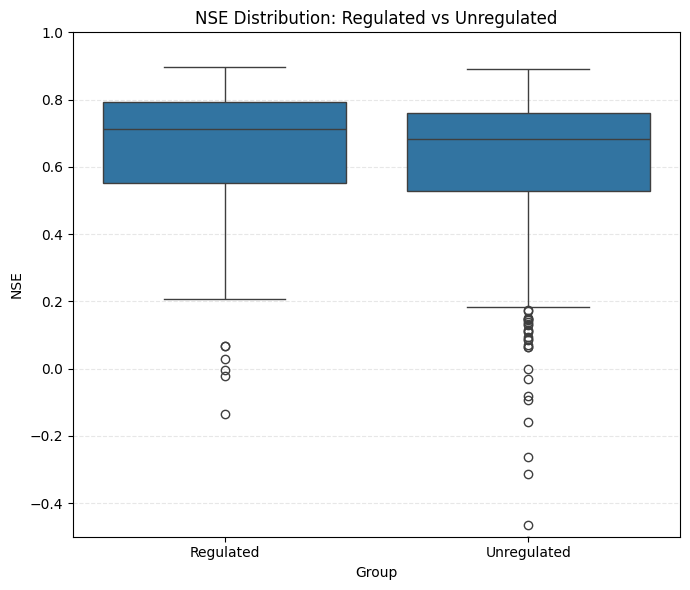

In [7]:
# Boxplot: NSE for Regulated vs Unregulated

# Combine data for plotting
plot_df = analysis_df.copy()
plot_df['Regulation'] = np.where(plot_df['dor_pc_pva'] > 0, 'Regulated', 'Unregulated')

# Set y-axis limits (adjust as needed)
ymin, ymax = -0.5, 1.0  # Change these values to filter out extreme values

plt.figure(figsize=(7, 6))
sns.boxplot(x='Regulation', y='NSE', data=plot_df, order=['Regulated', 'Unregulated'])
plt.title('NSE Distribution: Regulated vs Unregulated')
plt.xlabel('Group')
plt.ylabel('NSE')
plt.ylim((ymin, ymax))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 2 NSE distribution by Basin Size 

The basins are divided into 5 groups based on their size.
The area bins are divided so that each bin contains the same number of basins.

- Bin 1: 4.8 km² - 71.9 km²
- Bin 2: 72.9 km² - 194.7 km²
- Bin 3: 195.7 km² - 472.4 km²
- Bin 4: 475.2 km² - 1,336.6 km²
- Bin 5: 1,341.5 km² - 16,387.6 km²


--- 2. ANOVA by Area (5 Quantile Bins) ---

Area Bins created based on quantiles:
                  min           max  count
area_bin                                  
Bin 1        4.848310     71.920459    130
Bin 2       72.894505    194.721999    129
Bin 3      195.668890    472.395888    129
Bin 4      475.172976   1336.612836    129
Bin 5     1341.526498  16387.626962    130

ANOVA Results (NSE by Area Bin):
                   sum_sq     df         F    PR(>F)
C(area_bin)    679.355148    4.0  1.397549  0.233245
Residual     78019.820006  642.0       NaN       NaN

ANOVA result is not significant (p >= 0.05). No post-hoc test needed.
--------------------------------------------------


C:\Users\ybrot\AppData\Local\Temp\ipykernel_138736\2128826376.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_ranges = area_anova_df.groupby('area_bin')['area'].agg(['min', 'max', 'count'])
C:\Users\ybrot\AppData\Local\Temp\ipykernel_138736\2128826376.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_anova_area = anova_table_area['PR(>F)'][0]
C:\Users\ybrot\AppData\Local\Temp\ipykernel_138736\2128826376.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels) # Set the custom labels


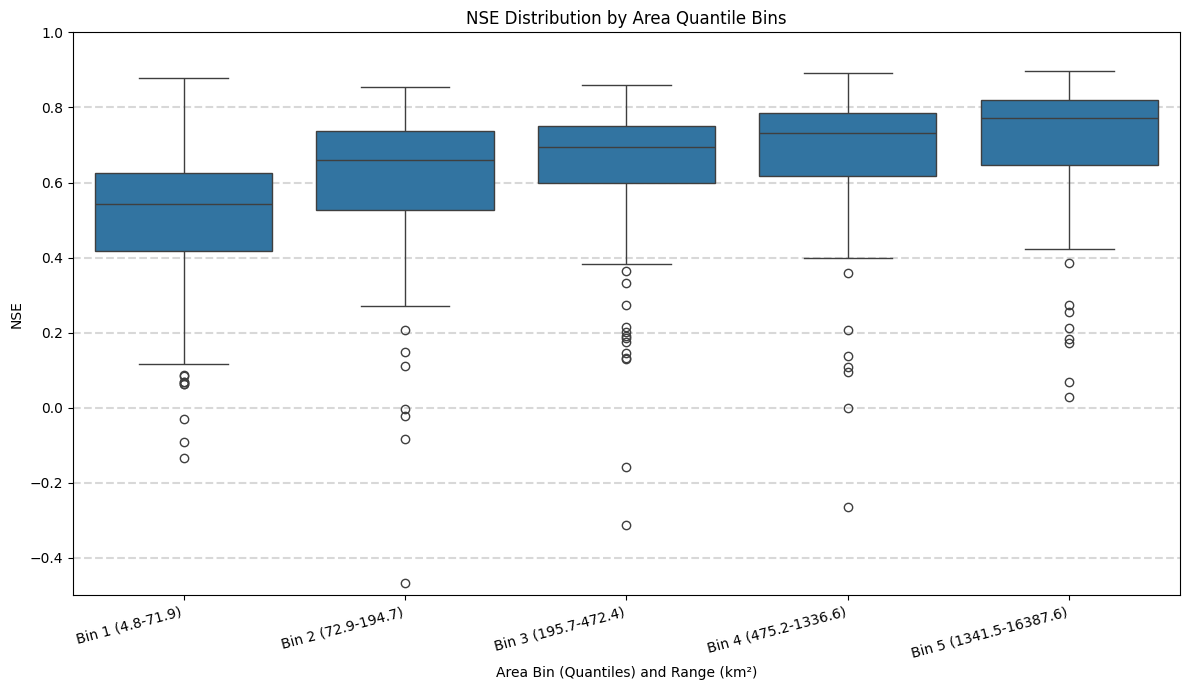

In [11]:
# In a new code cell

# --- 2a. ANOVA by Area (5 Quantile Bins) ---

print("\n--- 2. ANOVA by Area (5 Quantile Bins) ---")

# Ensure no NaNs in relevant columns for this analysis
area_anova_df = merged_df.dropna(subset=['NSE', 'area']).copy()

# Create 5 quantile bins for Area
# Using duplicates='drop' in case quantiles fall on the same area value
try:
    area_anova_df['area_bin'] = pd.qcut(area_anova_df['area'], q=5, labels=[f'Bin {i+1}' for i in range(5)], duplicates='drop')
    n_bins = area_anova_df['area_bin'].nunique()
    if n_bins < 5:
        print(f"Warning: Could only create {n_bins} bins due to duplicate area values at quantiles.")
        # Relabel if necessary
        area_anova_df['area_bin'] = pd.qcut(area_anova_df['area'], q=n_bins, labels=[f'Bin {i+1}' for i in range(n_bins)], duplicates='drop')


    print("\nArea Bins created based on quantiles:")
    # Store bin ranges
    bin_ranges = area_anova_df.groupby('area_bin')['area'].agg(['min', 'max', 'count'])
    print(bin_ranges)

    # Perform ANOVA
    model_area = ols('NSE ~ C(area_bin)', data=area_anova_df).fit()
    anova_table_area = sm.stats.anova_lm(model_area, typ=2)

    print("\nANOVA Results (NSE by Area Bin):")
    print(anova_table_area)

    # Check for significance
    p_value_anova_area = anova_table_area['PR(>F)'][0]
    if p_value_anova_area < 0.05:
        print("\nANOVA result is significant (p < 0.05). Performing Tukey's HSD test.")
        # Perform Tukey's HSD test
        tukey_area = pairwise_tukeyhsd(endog=area_anova_df['NSE'],
                                       groups=area_anova_df['area_bin'],
                                       alpha=0.05)
        print("\nTukey's HSD Post-Hoc Test Results:")
        print(tukey_area)
    else:
        print("\nANOVA result is not significant (p >= 0.05). No post-hoc test needed.")

except ValueError as e:
    print(f"\nError creating bins or performing ANOVA: {e}")
    print("This might happen if there are too few unique area values or insufficient data.")

print("-" * 50)

# Optional: Boxplot visualization
plt.figure(figsize=(12, 7)) # Adjusted figure size for longer labels
# Add horizontal lines
for y in np.arange(-0.4, 1.2, 0.2):
    plt.axhline(y, color='gray', linestyle='--', alpha=0.3)

# Create custom labels for x-axis
# Ensure bin_ranges exists and matches the bins plotted
if 'bin_ranges' in locals() and len(bin_ranges) == area_anova_df['area_bin'].nunique():
    x_labels = [f"{idx} ({row['min']:.1f}-{row['max']:.1f})" for idx, row in bin_ranges.iterrows()]
else:
    # Fallback if bin_ranges calculation failed or doesn't match
    x_labels = sorted(area_anova_df['area_bin'].unique())


ax = sns.boxplot(x='area_bin', y='NSE', data=area_anova_df, order=sorted(area_anova_df['area_bin'].unique())) # Ensure order matches labels
ax.set_xticklabels(x_labels) # Set the custom labels

plt.ylim((-0.5, 1))
plt.title('NSE Distribution by Area Quantile Bins')
plt.xlabel('Area Bin (Quantiles) and Range (km²)') # Updated label description
plt.ylabel('NSE')
plt.xticks(rotation=15, ha='right') # Slightly rotate if labels overlap
plt.tight_layout() # Adjust layout


plt.show()


--- 3. ANOVA by Area (Using Bins from Step 2, Lowest 1% NSE Removed) ---

Removing NSE values below the 1st percentile: -5.5462
Number of samples after removing low NSE values: 640

Counts per original Area Bin after filtering low NSE values:
area_bin
Bin 1    130
Bin 2    129
Bin 3    126
Bin 4    129
Bin 5    126
Name: count, dtype: int64

ANOVA Results (NSE by Original Area Bin, Filtered Data):
                 sum_sq     df         F    PR(>F)
C(area_bin)    3.766101    4.0  4.819278  0.000779
Residual     124.057679  635.0       NaN       NaN

ANOVA result is significant (p < 0.05). Performing Tukey's HSD test.

Tukey's HSD Post-Hoc Test Results (Filtered Data, Original Bins):
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 Bin 1  Bin 2   0.1161 0.2151 -0.0341 0.2664  False
 Bin 1  Bin 3   0.1976 0.0034  0.0465 0.3488   True
 Bin 1  Bin 4   0.2005 0.0026  0.0502 0.3508   T

C:\Users\ybrot\AppData\Local\Temp\ipykernel_138736\3122729435.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(final_plot_labels)


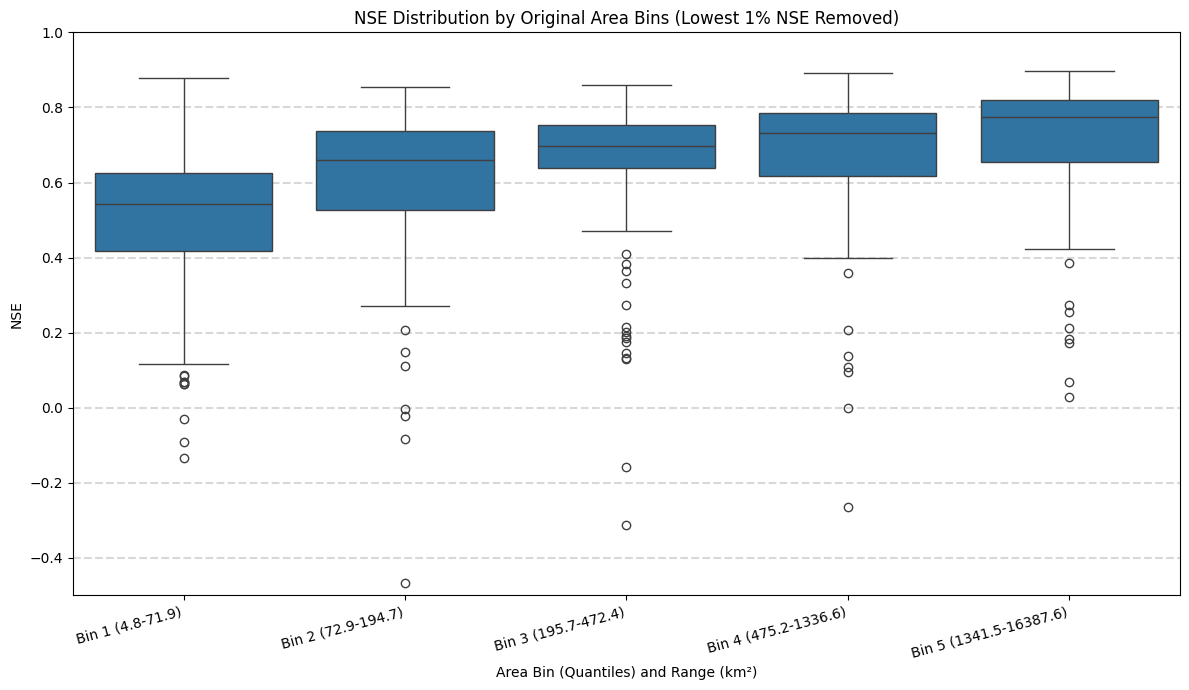

In [12]:
# In a new code cell

# --- 2b. ANOVA by Area (Using Bins from Step 2, Lowest 1% NSE Removed) ---

print("\n--- 3. ANOVA by Area (Using Bins from Step 2, Lowest 1% NSE Removed) ---")

# Ensure no NaNs in relevant columns
# Start with the original dataframe used for binning in step 2
area_anova_filtered_df = area_anova_df.copy() # Use the df from step 2 which already has area_bin

# Calculate the 1st percentile of NSE from this dataframe (before filtering but after dropping initial NaNs)
nse_percentile_1 = area_anova_filtered_df['NSE'].quantile(0.01)
print(f"\nRemoving NSE values below the 1st percentile: {nse_percentile_1:.4f}")

# Filter the DataFrame based on NSE percentile
area_anova_filtered_df = area_anova_filtered_df[area_anova_filtered_df['NSE'] >= nse_percentile_1].copy() # Use .copy() to avoid SettingWithCopyWarning
print(f"Number of samples after removing low NSE values: {len(area_anova_filtered_df)}")

# The 'area_bin' column from step 2 is already present in area_anova_filtered_df
# Verify counts per bin after filtering
print("\nCounts per original Area Bin after filtering low NSE values:")
print(area_anova_filtered_df['area_bin'].value_counts().sort_index()) # Sort index to match bin order

# Check if any bins became empty after filtering
if area_anova_filtered_df['area_bin'].nunique() < n_bins: # n_bins from step 2
     print(f"Warning: After filtering, only {area_anova_filtered_df['area_bin'].nunique()} bins have data.")

# Perform ANOVA on the filtered data using the original bins
try:
    # Ensure there's enough data in at least two bins to perform ANOVA
    if area_anova_filtered_df['area_bin'].nunique() >= 2:
        model_area_filtered = ols('NSE ~ C(area_bin)', data=area_anova_filtered_df).fit()
        anova_table_area_filtered = sm.stats.anova_lm(model_area_filtered, typ=2)

        print("\nANOVA Results (NSE by Original Area Bin, Filtered Data):")
        print(anova_table_area_filtered)

        # Check for significance
        # Note: Index might be different if a bin became empty, access p-value carefully
        p_value_anova_area_filtered = anova_table_area_filtered.loc['C(area_bin)', 'PR(>F)'] # Access by index name

        if p_value_anova_area_filtered < 0.05:
            print("\nANOVA result is significant (p < 0.05). Performing Tukey's HSD test.")
            # Perform Tukey's HSD test
            tukey_area_filtered = pairwise_tukeyhsd(endog=area_anova_filtered_df['NSE'],
                                                    groups=area_anova_filtered_df['area_bin'], # Use the original bin assignment
                                                    alpha=0.05)
            print("\nTukey's HSD Post-Hoc Test Results (Filtered Data, Original Bins):")
            print(tukey_area_filtered)
        else:
            print("\nANOVA result is not significant (p >= 0.05). No post-hoc test needed.")
    else:
        print("\nSkipping ANOVA: Not enough bins with data after filtering.")

except Exception as e: # Catch potential errors during ANOVA/Tukey
    print(f"\nError performing ANOVA or Tukey's HSD on filtered data: {e}")

print("-" * 50)

# Optional: Boxplot visualization using original bins and filtered data
plt.figure(figsize=(12, 7)) # Adjusted figure size
# Add horizontal lines
for y in np.arange(-0.4, 1.2, 0.2):
    plt.axhline(y, color='gray', linestyle='--', alpha=0.3)

# Use the same x_labels created in step 2
# Ensure bin_ranges and x_labels from step 2 are available
if 'bin_ranges' in locals() and 'x_labels' in locals() and len(bin_ranges) == n_bins:
     # Ensure the order matches the unique bins present in the filtered data for plotting
    plot_order = sorted(area_anova_filtered_df['area_bin'].unique())
    # Filter x_labels to only include those bins present in plot_order
    filtered_x_labels = [lbl for lbl in x_labels if any(f"Bin {i+1}" in lbl for i, b in enumerate(plot_order) if f"Bin {i+1}" == b)]

    ax = sns.boxplot(x='area_bin', y='NSE', data=area_anova_filtered_df, order=plot_order)
    # Set the filtered labels corresponding to the plot_order
    # This assumes x_labels were created like "Bin 1 (min-max)", "Bin 2 (min-max)", etc.
    label_map = {f"Bin {i+1}": lbl for i, lbl in enumerate(x_labels)}
    final_plot_labels = [label_map[bin_name] for bin_name in plot_order]
    ax.set_xticklabels(final_plot_labels)

else:
    # Fallback if labels from step 2 aren't available
    print("Warning: Bin range labels from step 2 not found. Using default bin names.")
    ax = sns.boxplot(x='area_bin', y='NSE', data=area_anova_filtered_df, order=sorted(area_anova_filtered_df['area_bin'].unique()))


plt.ylim((-0.5, 1)) # Keep consistent y-axis limits if desired
plt.title('NSE Distribution by Original Area Bins (Lowest 1% NSE Removed)')
plt.xlabel('Area Bin (Quantiles) and Range (km²)') # Use the descriptive label
plt.ylabel('NSE')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 3. NSE distribution by Land Use


--- 4. ANOVA by Basin Category ---

Basin Categories and Counts:
basin_category
MX    224
UD    223
AG    140
UR     60
Name: count, dtype: int64

ANOVA Results (NSE by Basin Category):
                         sum_sq     df        F    PR(>F)
C(basin_category)    299.951992    3.0  0.82003  0.483057
Residual           78399.223162  643.0      NaN       NaN

ANOVA result is not significant (p >= 0.05). No post-hoc test needed.
--------------------------------------------------


C:\Users\ybrot\AppData\Local\Temp\ipykernel_138736\1638832942.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_anova_category = anova_table_category['PR(>F)'][0]


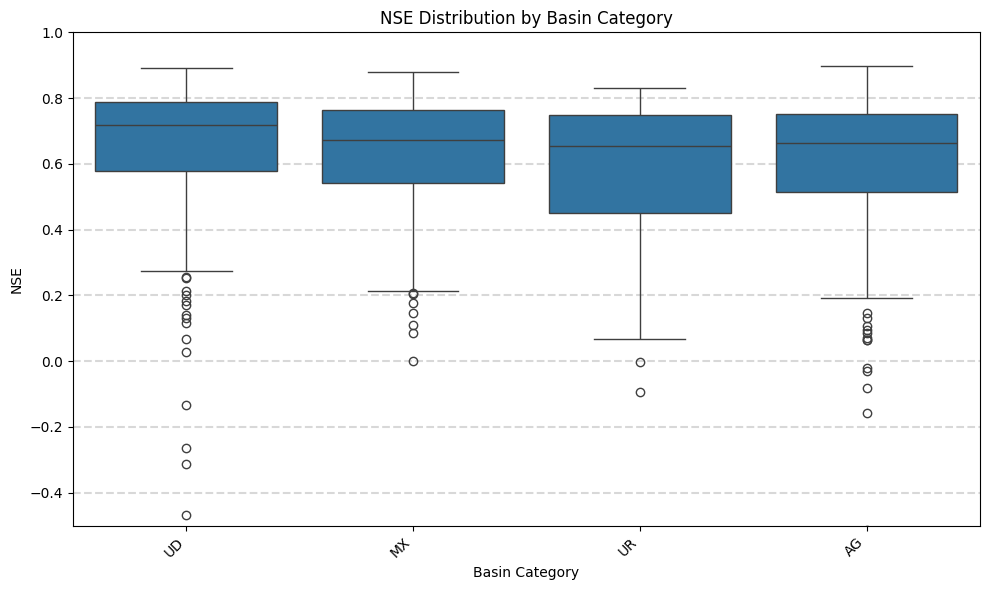

In [13]:
# In a new code cell

# --- 3. ANOVA by Basin Category ---

print("\n--- 4. ANOVA by Basin Category ---")

# Ensure no NaNs in relevant columns
category_anova_df = merged_df.dropna(subset=['NSE', 'basin_category']).copy()

print("\nBasin Categories and Counts:")
print(category_anova_df['basin_category'].value_counts())

# Perform ANOVA
# Using C() to explicitly treat 'basin_category' as categorical
model_category = ols('NSE ~ C(basin_category)', data=category_anova_df).fit()
anova_table_category = sm.stats.anova_lm(model_category, typ=2)

print("\nANOVA Results (NSE by Basin Category):")
print(anova_table_category)

# Check for significance
p_value_anova_category = anova_table_category['PR(>F)'][0]
if p_value_anova_category < 0.05:
    print("\nANOVA result is significant (p < 0.05). Performing Tukey's HSD test.")
    # Perform Tukey's HSD test
    tukey_category = pairwise_tukeyhsd(endog=category_anova_df['NSE'],
                                       groups=category_anova_df['basin_category'],
                                       alpha=0.05)
    print("\nTukey's HSD Post-Hoc Test Results:")
    print(tukey_category)
else:
    print("\nANOVA result is not significant (p >= 0.05). No post-hoc test needed.")

print("-" * 50)

# Optional: Boxplot visualization
plt.figure(figsize=(10, 6))
for y in np.arange(-0.4, 1.2, 0.2):
    plt.axhline(y, color='gray', linestyle='--', alpha=0.3)

sns.boxplot(x='basin_category', y='NSE', data=category_anova_df)
plt.ylim((-0.5, 1))
plt.title('NSE Distribution by Basin Category')
plt.xlabel('Basin Category')
plt.ylabel('NSE')
plt.xticks(rotation=45, ha='right') # Rotate labels if they overlap
plt.tight_layout()
plt.show()

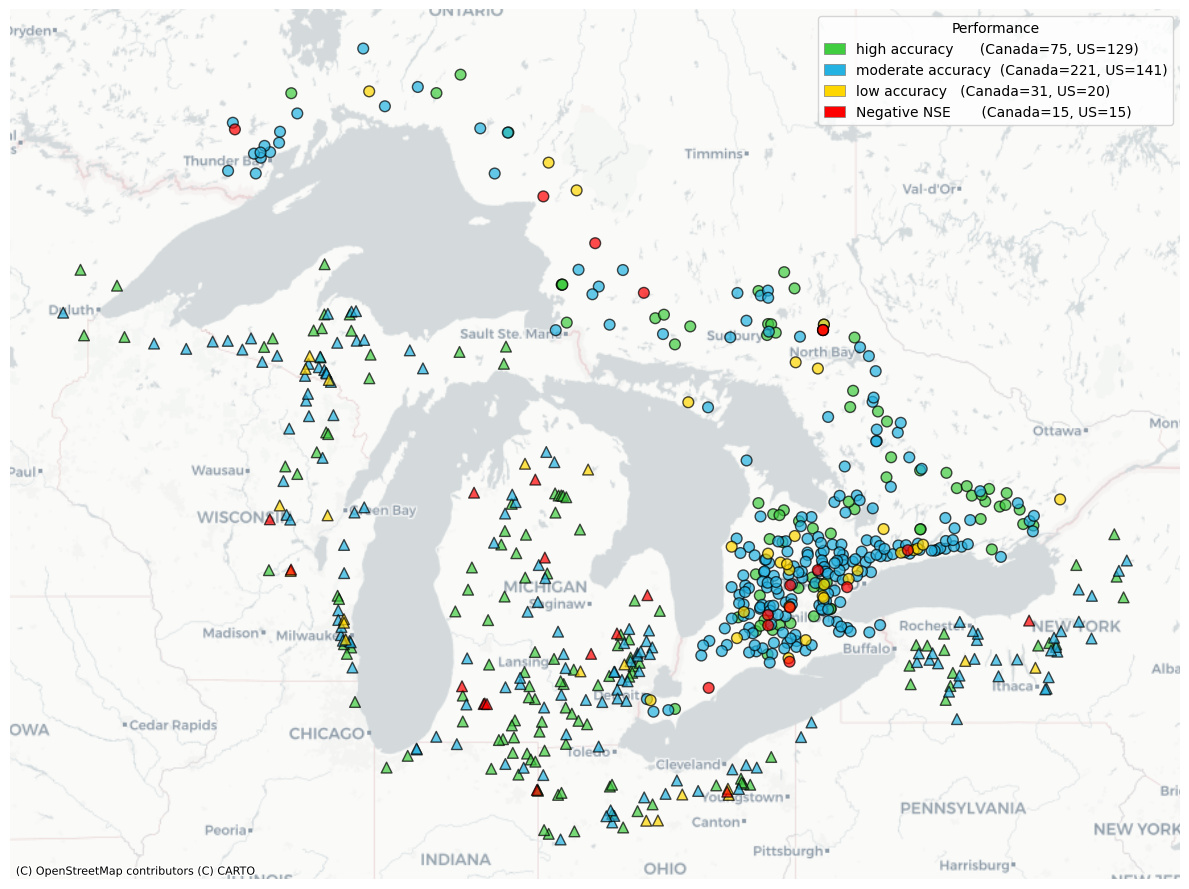

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.patches import Rectangle

# 1. Paths to your data
can_shp = "../metadata/shapefile/ADP02_Basin_Select.shp"
us_shp  = "../metadata/shapefile/GL_GAGE2_all.shp"
csv_fp  = "./csv_files/result.csv"

# 2. Load & normalize the Canadian basins
can = gpd.read_file(can_shp).to_crs(epsg=3857)
can = can.rename(columns={"StationNum": "basin_id"})
can["basin_id"] = can["basin_id"].astype(str)
can["country"] = "Canada"

# 3. Load & normalize the US basins
us = gpd.read_file(us_shp).to_crs(epsg=3857)
us = us.rename(columns={"GAGE_ID": "basin_id"})
us["basin_id"] = us["basin_id"].astype(str)
us["country"] = "US"

# 4. Combine both GeoDataFrames
gdf = pd.concat([can, us], ignore_index=True)

# 5. Load your performance results
df = pd.read_csv(csv_fp, dtype={"basin_id": str})

# 6. Merge on basin_id and drop any with no label
gdf = gdf.merge(df, on="basin_id", how="left")
gdf = gdf[gdf["Performance"].notna()]

# 7. Compute centroids for plotting
gdf["x"] = gdf.geometry.centroid.x
gdf["y"] = gdf.geometry.centroid.y

# 8. Assign marker shapes: circle for Canada, triangle for US
gdf["marker"] = np.where(gdf["country"] == "Canada", "o", "^")

# 9. Define your light‐shade color map
color_map = {
    "Excellent":      "#40cd40",  # light green
    "Good":           "#23b2e1",  # light blue
    "Unsatisfactory": "gold",
    "Negative":       "red"
}
gdf["color"] = gdf["Performance"].map(color_map)

# 10. Begin plotting
fig, ax = plt.subplots(figsize=(12, 9))

for label, col in color_map.items():
    for mk in ["o", "^"]:
        subset = gdf[(gdf.Performance == label) & (gdf.marker == mk)]
        if subset.empty:
            continue
        ax.scatter(
            subset["x"], subset["y"],
            c=subset["color"],
            marker=mk,
            edgecolor="black",
            linewidth=1,
            s=60,
            alpha=0.7
        )

# 11. Add the CartoDB Positron basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# 12. Remove axes
ax.set_axis_off()

# 13. Build legend entries with rectangle swatches
counts = {
    lbl: {
        "Canada": int(((gdf.country == "Canada") & (gdf.Performance == lbl)).sum()),
        "US":      int(((gdf.country == "US")      & (gdf.Performance == lbl)).sum())
    }
    for lbl in color_map
}

legend_info = [
    (color_map["Excellent"], f"high accuracy (Canada={counts['Excellent']['Canada']}, US={counts['Excellent']['US']})"),
    (color_map["Good"],      f"moderate accuracy (Canada={counts['Good']['Canada']}, US={counts['Good']['US']})"),
    (color_map["Unsatisfactory"], f"low accuracy (Canada={counts['Unsatisfactory']['Canada']}, US={counts['Unsatisfactory']['US']})"),
    (color_map["Negative"],  f"Negative NSE (Canada={counts['Negative']['Canada']}, US={counts['Negative']['US']})"),
]

proxies = [
    Rectangle((0,0), 1, 0.5,
              facecolor=col,
              edgecolor="gray",
              linewidth=0.5)
    for col, _ in legend_info
]
labels = [lbl for _, lbl in legend_info]

ax.legend(
    proxies,
    labels,
    title="Performance",
    loc="upper right",
    frameon=True,
    handlelength=1.5,
    handleheight=0.8
)

# 14. Finish
plt.tight_layout()
plt.show()
